In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from unstructured_client import UnstructuredClient
from unstructured_client.models import shared
from unstructured_client.models.errors import SDKError
from unstructured.partition.html import partition_html
from unstructured.partition.pdf import partition_pdf
from unstructured_client.models import operations

import os
from dotenv import load_dotenv

from unstructured.staging.base import dict_to_elements

In [3]:
load_dotenv()

api_key = os.getenv("UNSTRUCTURED_API_KEY")

In [4]:
from Utils import Utils
from unstructured_client import UnstructuredClient

utils = Utils()

API_KEY = utils.get_api_key()
API_URL = utils.get_url()

s = UnstructuredClient(
    api_key_auth=API_KEY,
    server_url=API_URL,
)


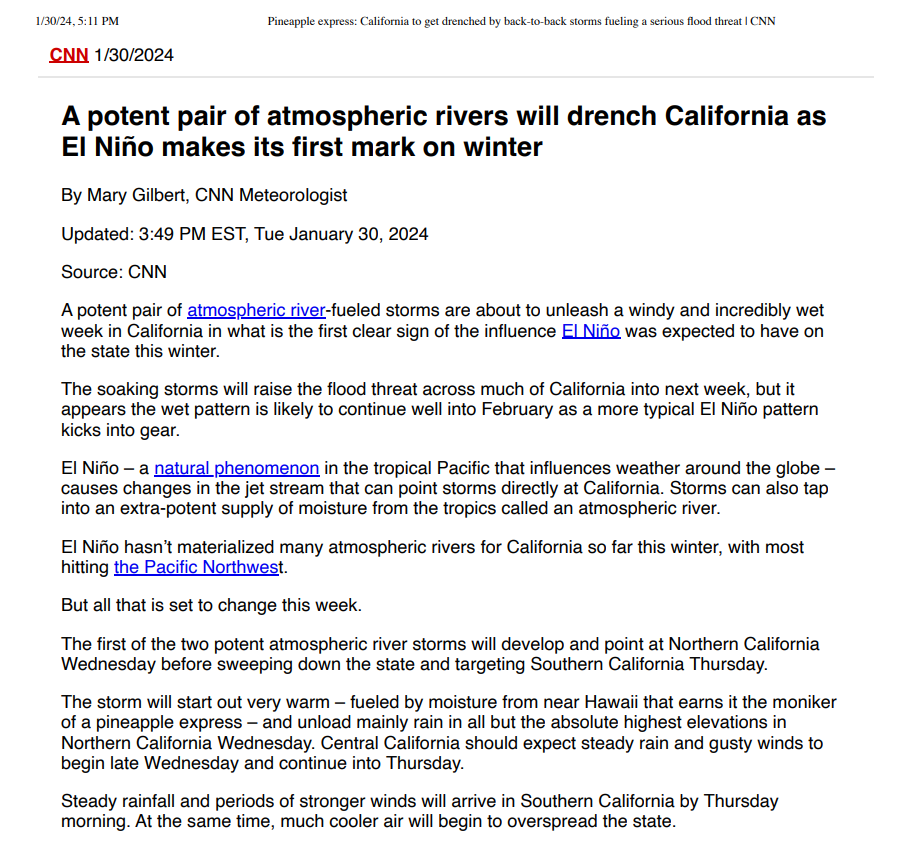

In [5]:
from IPython.display import Image
Image(filename="el_nino.png", height=600, width=600)

In [6]:
filename = "el_nino.html"
html_elements = partition_html(filename=filename)

In [7]:
import pytesseract

pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

In [8]:
import pytesseract
print(pytesseract.get_tesseract_version())

5.5.0.20241111


In [9]:
import os

# Add Tesseract to PATH manually
os.environ["PATH"] += r";C:\Program Files\Tesseract-OCR"

# (Optional but safe)
os.environ["TESSERACT_CMD"] = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

In [10]:
pdf_elements = partition_pdf(
    filename="el_nino.pdf",
    strategy="hi_res",
    languages=["eng"]
)

INFO: pikepdf C++ to Python logger bridge initialized
INFO: HTTP Request: HEAD https://huggingface.co/unstructuredio/yolo_x_layout/resolve/main/yolox_l0.05.onnx "HTTP/1.1 302 Found"
INFO: Reading PDF for file: el_nino.pdf ...


In [11]:
for element in html_elements[:10]:
    print(f"{element.category.upper()}: {element.text}")

TITLE: El Niño
NARRATIVETEXT: El Niño is a climate pattern that describes the unusual warming of surface waters in the eastern tropical Pacific Ocean.
TITLE: What Causes El Niño?
NARRATIVETEXT: El Niño occurs when trade winds weaken. Warm water is pushed back east toward the west coast of the Americas.
NARRATIVETEXT: This warm water changes global weather patterns and affects rainfall, storms, and temperatures.
TITLE: Effects of El Niño
NARRATIVETEXT: El Niño can cause heavy rainfall in some regions and droughts in others.
LISTITEM: Flooding in South America
LISTITEM: Drought in Australia
LISTITEM: Warmer winters in North America


In [12]:

with open(filename, "rb") as f:
    files = shared.Files(
        content=f.read(),
        file_name=filename,
    )

req = shared.PartitionParameters(
    files=files,
    strategy="hi_res",
    hi_res_model_name="yolox",
)

try:
    resp = s.general.partition(
        request=operations.PartitionRequest(
            partition_parameters=req
        )
    )

    dld_elements = dict_to_elements(resp.elements)

except SDKError as e:
    print(e)

INFO: HTTP Request: POST https://api.unstructuredapp.io/general/v0/general "HTTP/1.1 200 OK"


In [13]:
for element in dld_elements[:10]:
    print(f"{element.category.upper()}: {element.text}")

TITLE: El Niño
NARRATIVETEXT: El Niño is a climate pattern that describes the unusual warming of surface waters in the eastern tropical Pacific Ocean.
TITLE: What Causes El Niño?
NARRATIVETEXT: El Niño occurs when trade winds weaken. Warm water is pushed back east toward the west coast of the Americas.
NARRATIVETEXT: This warm water changes global weather patterns and affects rainfall, storms, and temperatures.
TITLE: Effects of El Niño
NARRATIVETEXT: El Niño can cause heavy rainfall in some regions and droughts in others.
LISTITEM: Flooding in South America
LISTITEM: Drought in Australia
LISTITEM: Warmer winters in North America


In [14]:
import collections

In [15]:
len(html_elements)

21

In [16]:
html_categories = [el.category for el in html_elements]
collections.Counter(html_categories).most_common()

[('NarrativeText', 9), ('Title', 8), ('ListItem', 4)]

In [17]:
len(dld_elements)

21

In [18]:
dld_categories = [el.category for el in dld_elements]
collections.Counter(dld_categories).most_common()

[('NarrativeText', 9), ('Title', 8), ('ListItem', 4)]